In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [2]:
# Debug: Check dataset structure
ds = xr.open_dataset("sst.day.mean.2024.nc")
print("Dataset dimensions:", ds.dims)
print("Latitude range:", ds['lat'].min().values, "to", ds['lat'].max().values)
print("Longitude range:", ds['lon'].min().values, "to", ds['lon'].max().values)
print("Latitude size:", len(ds['lat']))
print("Longitude size:", len(ds['lon']))

Dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 366, 'lat': 720, 'lon': 1440})
Latitude range: -89.875 to 89.875
Longitude range: 0.125 to 359.875
Latitude size: 720
Longitude size: 1440


KeyboardInterrupt: 

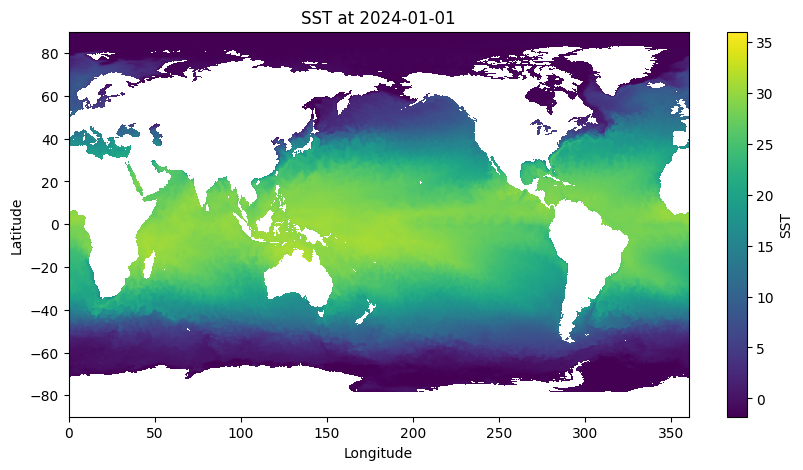

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# -------------------------
# Load dataset
# -------------------------
ds = xr.open_dataset("sst.day.mean.2024.nc")

# Extract variables
sst = ds['sst']          # (time, lat, lon)
lat = ds['lat']
lon = ds['lon']
time = ds['time']

# -------------------------
# Choose colour scale
# NOAA SST in Kelvin → convert to Celsius if you want
# sst = sst - 273.15
# -------------------------
vmin = float(sst.min())
vmax = float(sst.max())

# -------------------------
# Create figure
# -------------------------
fig, ax = plt.subplots(figsize=(10,5))

# Initial frame
frame0 = sst.isel(time=0)
quad = ax.pcolormesh(lon, lat, frame0,
                     shading='auto', vmin=vmin, vmax=vmax)

cbar = fig.colorbar(quad, label="SST")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

def format_time(t):
    """Format datetime for title."""
    try:
        return np.datetime_as_string(np.array(t, dtype='datetime64[ns]'), unit='D')
    except:
        return str(t.values)

ax.set_title(f"SST at {format_time(time.isel(time=0))}")

# -------------------------
# Update function
# -------------------------
def update(frame_index):
    frame = sst.isel(time=frame_index)

    quad.set_array(frame.values.ravel())
    ax.set_title(f"SST at {format_time(time.isel(time=frame_index))}")
    return quad,

# -------------------------
# Build animation
# -------------------------
anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(time),
    interval=100,   # milliseconds per frame
    blit=False
)

# -------------------------
# Save as GIF
# -------------------------
anim.save("sst_2024.gif", writer="pillow", fps=10)

plt.close(fig)

In [ ]:
import pickle
import os
import numpy as np

# Create X, Y, U, T in XUYT form similar to main_gaussian_pulse

# X and Y are 2D meshgrids from lon and lat
lon_vals = ds['lon'].values
lat_vals = ds['lat'].values
X, Y = np.meshgrid(lon_vals, lat_vals)

# U is a list of 2D arrays for each time step
U = [ds['sst'].isel(time=i).values for i in range(len(ds['time']))]

# T is the time array
T = ds['time'].values

# Save to pickle file
save_path = os.path.join(os.getcwd(), 'sst_data.pkl')
data = {'X': X, 'Y': Y, 'U': U, 'T': T}
with open(save_path, 'wb') as f:
    pickle.dump(data, f)

print(f"Variables saved to {save_path}")